In [8]:
import pandas as pd
import numpy as np
import networkx as nx
from numpy.linalg import inv
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# ==========================================
# STEP 0: Generate Mock Database
# ==========================================
print("Step 0: Generating Mock Database...")
np.random.seed(42)

users = pd.DataFrame({'user_id': range(1, 51)})
items = pd.DataFrame({'item_id': range(1, 101)})

# Create 200 random purchases
purchases = pd.DataFrame({
    'purchase_id': range(1, 201),
    'user_id': np.random.choice(users['user_id'], 200),
    'item_id': np.random.choice(items['item_id'], 200)
}).drop_duplicates(subset=['user_id', 'item_id'])

# ==========================================
# STEP 1: Initialize the Target Feature Dataset
# ==========================================
print("Step 1: Initializing the target_df Dataset...")
# Use Pandas native cross-join to create every possible User-Item pair
target_df = users[['user_id']].merge(items[['item_id']], how='cross')

# Label our Ground Truth: 1 if the purchase exists in the database, 0 if not
actual_purchases = set(zip(purchases['user_id'], purchases['item_id']))
target_df['label'] = target_df.apply(
    lambda row: 1 if (row['user_id'], row['item_id']) in actual_purchases else 0,
    axis=1
)

# ==========================================
# STEP 2: Build the Heterogeneous Graph
# ==========================================
print("Step 2: Building NetworkX Graph...")
G = nx.Graph()

# Add all nodes
G.add_nodes_from([(("User", row['user_id']), {"label": "User"}) for _, row in users.iterrows()])
G.add_nodes_from([(("Item", row['item_id']), {"label": "Item"}) for _, row in items.iterrows()])
G.add_nodes_from([(("Purchase", row['purchase_id']), {"label": "Purchase"}) for _, row in purchases.iterrows()])

# Add edges representing the schema: User <-> Purchase <-> Item
user_edges = [(("User", row['user_id']), ("Purchase", row['purchase_id'])) for row in purchases]
item_edges = [(("Item", row['item_id']), ("Purchase", row['purchase_id'])) for row in purchases]
G.add_edges_from(user_edges + item_edges)

# ==========================================
# STEP 3: Add RAW Node Features to Dataset
# ==========================================
print("Step 3: Enriching Dataset with Raw Node Degrees...")
degree_dict = dict(G.degree())

# We apply the raw extraction directly to our target_df columns
target_df['raw_user_degree'] = target_df['user_id'].apply(
    lambda u_id: degree_dict.get(("User", u_id), 0)
)

target_df['raw_item_degree'] = target_df['item_id'].apply(
    lambda i_id: degree_dict.get(("Item", i_id), 0)
)

# ==========================================
# STEP 4: Add Link Features (Katz) to Dataset
# ==========================================
print("Step 4: Enriching Dataset with Katz Index...")
node_list = list(G.nodes())

# Calculate Global Adjacency and Katz Matrices
A = nx.to_numpy_array(G, nodelist=node_list)
beta = 0.1
I = np.eye(G.number_of_nodes())
katz_matrix = inv(I - beta * A) - I

# Create fast lookup dictionaries for matrix row/col indices
u_idx_map = {node[1]: idx for idx, node in enumerate(node_list) if node[0] == "User"}
i_idx_map = {node[1]: idx for idx, node in enumerate(node_list) if node[0] == "Item"}
print(u_idx_map)
# Extract the specific pairwise score from the matrix for every row
target_df['katz_score'] = target_df.apply(
    lambda row: katz_matrix[u_idx_map[row['user_id']], i_idx_map[row['item_id']]],
    axis=1
)

# ==========================================
# STEP 5: EDA Transformations & ML Engineering
# ==========================================
print("Step 5: Normalizing features and Training Model...")

# Based on our EDA of the graph degree distribution, we apply log normalization
# to the raw features before feeding them to the model to prevent weight explosion.
target_df['user_norm_degree'] = np.log1p(target_df['raw_user_degree'])
target_df['item_norm_degree'] = np.log1p(target_df['raw_item_degree'])

# Balance the dataset (Negative Sampling)
positives = target_df[target_df['label'] == 1]
negatives = target_df[target_df['label'] == 0]
sampled_negatives = negatives.sample(n=len(positives), random_state=42)

balanced_df = pd.concat([positives, sampled_negatives]).sample(frac=1, random_state=42).reset_index(drop=True)

# Train and Evaluate
# Notice we pass the normalized degrees to the model, not the raw ones
features = ['katz_score', 'user_norm_degree', 'item_norm_degree']
X = balanced_df[features]
y = balanced_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

predictions = clf.predict_proba(X_test)[:, 1]
print("==========================================")
print(f"✅ Pipeline Complete! Model AUC-ROC Score: {roc_auc_score(y_test, predictions):.3f}")
print("==========================================")

Step 0: Generating Mock Database...
Step 1: Initializing the target_df Dataset...
Step 2: Building NetworkX Graph...


TypeError: string indices must be integers, not 'str'

In [ ]:
import pandas as pd
users     = pd.read_csv("users.csv")
items     = pd.read_csv("items.csv")
purchases = pd.read_csv("purchases.csv")



In [ ]:
import networkx as nx
G = nx.Graph()

In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import networkit as nk
from numpy.linalg import inv
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# ==========================================
# STEP 0: Generate Mock Database
# ==========================================
print("Step 0: Generating Mock Database...")
np.random.seed(42)

users = pd.DataFrame({'user_id': range(1, 51)})
items = pd.DataFrame({'item_id': range(1, 101)})

# Create 200 random purchases
purchases = pd.DataFrame({
    'purchase_id': range(1, 201),
    'user_id': np.random.choice(users['user_id'], 200),
    'item_id': np.random.choice(items['item_id'], 200)
}).drop_duplicates(subset=['user_id', 'item_id'])

# ==========================================
# STEP 1: Initialize the target_df Dataset
# ==========================================
print("Step 1: Initializing the target_df via Cartesian Product...")

# Use the optimized Pandas Cross-Join
target_df = users[['user_id']].merge(items[['item_id']], how='cross')

# Label Ground Truth: 1 if the purchase exists, 0 if not
actual_purchases = set(zip(purchases['user_id'], purchases['item_id']))
target_df['label'] = target_df.apply(
    lambda row: 1 if (row['user_id'], row['item_id']) in actual_purchases else 0,
    axis=1
)

# ==========================================
# STEP 2: Build the Heterogeneous Graph
# ==========================================
print("Step 2: Building NetworkX Graph (User <-> Purchase <-> Item)...")
G = nx.Graph()

# Add Nodes
G.add_nodes_from([(("User", row['user_id']), {"label": "User"}) for _, row in users.iterrows()])
G.add_nodes_from([(("Item", row['item_id']), {"label": "Item"}) for _, row in items.iterrows()])
G.add_nodes_from([(("Purchase", row['purchase_id']), {"label": "Purchase"}) for _, row in purchases.iterrows()])

# Add Edges
user_edges = [(("User", row['user_id']), ("Purchase", row['purchase_id'])) for _, row in purchases.iterrows()]
item_edges = [(("Item", row['item_id']), ("Purchase", row['purchase_id'])) for _, row in purchases.iterrows()]
G.add_edges_from(user_edges + item_edges)

# ==========================================
# STEP 3: Add RAW Node Features
# ==========================================
print("Step 3: Enriching target_df with RAW Node Degrees...")
degree_dict = dict(G.degree())

target_df['raw_user_degree'] = target_df['user_id'].apply(
    lambda u_id: degree_dict.get(("User", u_id), 0)
)

target_df['raw_item_degree'] = target_df['item_id'].apply(
    lambda i_id: degree_dict.get(("Item", i_id), 0)
)

# ==========================================
# STEP 4: Add Link Features (NetworKit Katz)
# ==========================================
print("Step 4: Enriching target_df with Katz Index (NetworKit)...")

# 1. Map complex Tuple IDs to NetworKit-friendly Integers
tuple_to_int_map = {node: i for i, node in enumerate(G.nodes())}
G_int = nx.relabel_nodes(G, tuple_to_int_map)
nk_graph = nk.nxadapter.nx2nk(G_int)

# 2. Fix: Use POSITIONAL arguments for NetworKit constructor
# ki = nk.linkprediction.KatzIndex(graph, maxPathLength, dampingValue)
ki = nk.linkprediction.KatzIndex(nk_graph, 5, 0.1)

# 3. Calculate score for each pair
target_df['katz_score'] = target_df.apply(
    lambda row: ki.run(
        tuple_to_int_map[("User", row['user_id'])],
        tuple_to_int_map[("Item", row['item_id'])]
    ),
    axis=1
)

# ==========================================
# STEP 5: Final Normalization & Training
# ==========================================
print("Step 5: Normalizing and Training Model...")

# Sequential Feature Creation: Normalize the raw columns created in Step 3
target_df['user_norm_degree'] = np.log1p(target_df['raw_user_degree'])
target_df['item_norm_degree'] = np.log1p(target_df['raw_item_degree'])

# Negative Sampling for Class Balance
positives = target_df[target_df['label'] == 1]
negatives = target_df[target_df['label'] == 0]
sampled_negatives = negatives.sample(n=len(positives), random_state=42)

balanced_df = pd.concat([positives, sampled_negatives]).sample(frac=1, random_state=42)

# Select features and labels
features = ['katz_score', 'user_norm_degree', 'item_norm_degree']
X = balanced_df[features]
y = balanced_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Output Results
predictions = clf.predict_proba(X_test)[:, 1]
print("==========================================")
print(f"✅ Full Pipeline Complete! Model AUC-ROC: {roc_auc_score(y_test, predictions):.3f}")
print("==========================================")

Step 0: Generating Mock Database...
Step 1: Initializing the target_df via Cartesian Product...
Step 2: Building NetworkX Graph (User <-> Purchase <-> Item)...
Step 3: Enriching target_df with RAW Node Degrees...
Step 4: Enriching target_df with Katz Index (NetworKit)...
Step 5: Normalizing and Training Model...
✅ Full Pipeline Complete! Model AUC-ROC: 1.000


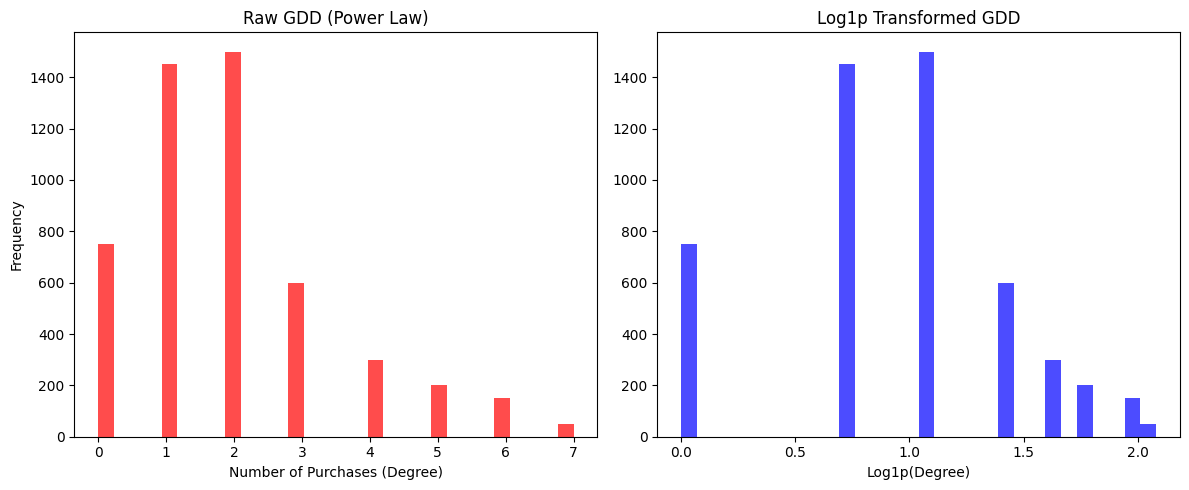

In [6]:
import matplotlib.pyplot as plt

# --- VISUALIZING THE GRAPH DEGREE DISTRIBUTION (GDD) ---

# 1. Get all the raw item degrees
item_degrees = target_df['raw_item_degree'].values

# 2. Plot the raw GDD (It will look like a steep cliff / power law)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(item_degrees, bins=30, color='red', alpha=0.7)
plt.title("Raw GDD (Power Law)")
plt.xlabel("Number of Purchases (Degree)")
plt.ylabel("Frequency")

# 3. Plot the Log-Transformed GDD (It will look much more balanced)
plt.subplot(1, 2, 2)
plt.hist(np.log1p(item_degrees), bins=30, color='blue', alpha=0.7)
plt.title("Log1p Transformed GDD")
plt.xlabel("Log1p(Degree)")

plt.tight_layout()
plt.show()

In [8]:
from collections import Counter

print("==========================================")
print("Calculating 1-WL Color Distribution (NetworkX)...")

# 1. Run the built-in NetworkX 1-WL algorithm
# iterations=2 corresponds to a 2-layer MPNN
# node_attr='label' uses the "User", "Item", "Purchase" labels we created in Step 2
wl_hashes = nx.weisfeiler_lehman_subgraph_hashes(G, node_attr='label', iterations=2)

# 2. Extract the final color hash for each node
# The function returns a list of hashes (one for each iteration depth).
# We want the final state, so we take the last element [-1] of the list.
final_colors = [hashes[-1] for node, hashes in wl_hashes.items()]

# 3. Count how many nodes share the exact same structural subtree
color_distribution = Counter(final_colors)

print(f"\nGraph Expressivity after 2 WL Iterations:")
print(f"Total Nodes: {G.number_of_nodes()} | Unique Colors Found: {len(color_distribution)}")
print("-" * 40)

# Print the distribution
for color_hash, count in color_distribution.most_common():
    # We slice the hex string to 6 characters to make the printout clean and readable
    print(f"Structural Color [{color_hash[:6]}] : Shared by {count} nodes")
print("==========================================")

Calculating 1-WL Color Distribution (NetworkX)...

Graph Expressivity after 2 WL Iterations:
Total Nodes: 344 | Unique Colors Found: 72
----------------------------------------
Structural Color [cff600] : Shared by 30 nodes
Structural Color [4df158] : Shared by 29 nodes
Structural Color [60d075] : Shared by 15 nodes
Structural Color [343da0] : Shared by 14 nodes
Structural Color [62008e] : Shared by 12 nodes
Structural Color [f8b189] : Shared by 12 nodes
Structural Color [d70fa8] : Shared by 11 nodes
Structural Color [728175] : Shared by 11 nodes
Structural Color [8f0c16] : Shared by 10 nodes
Structural Color [7e8c48] : Shared by 9 nodes
Structural Color [47aa5a] : Shared by 9 nodes
Structural Color [0a0197] : Shared by 8 nodes
Structural Color [ac7203] : Shared by 8 nodes
Structural Color [eb6d06] : Shared by 7 nodes
Structural Color [a58d61] : Shared by 6 nodes
Structural Color [a2c81e] : Shared by 6 nodes
Structural Color [b8ebf3] : Shared by 6 nodes
Structural Color [cce5b6] : Shar

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import networkit as nk
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# ==========================================
# STEP 0: Generate Structured Mock Database
# ==========================================
print("Step 0: Generating Mock Database with Latent Communities...")
np.random.seed(42)

n_users, n_items = 150, 300
user_groups = np.random.randint(0, 3, n_users)
item_groups = np.random.randint(0, 3, n_items)

all_possible_pairs = set()
all_actual_edges = []

for u in range(n_users):
    for i in range(n_items):
        all_possible_pairs.add((u+1, i+1))
        prob = 0.10 if user_groups[u] == item_groups[i] else 0.005
        if np.random.rand() < prob:
            all_actual_edges.append((u+1, i+1))

# ==========================================
# STEP 1: Define the Timeline Splits (No Leakage)
# ==========================================
print("Step 1: Defining the Historical vs. Future edges...")
np.random.shuffle(all_actual_edges)

# The "Past": 60% of data used EXCLUSIVELY to build the Graph
n_base = int(len(all_actual_edges) * 0.6)
edges_base = all_actual_edges[:n_base]

# The "Future": 40% of data we want to predict
edges_future = all_actual_edges[n_base:]
n_train = int(len(edges_future) * 0.5)

# Assign positive edges to Train/Test
train_pos = edges_future[:n_train]
test_pos = edges_future[n_train:]

# Generate Negative Samples (Edges that never happened)
non_edges = list(all_possible_pairs - set(all_actual_edges))
np.random.shuffle(non_edges)
train_neg = non_edges[:len(train_pos)]
test_neg = non_edges[len(train_pos):len(train_pos)+len(test_pos)]

# ==========================================
# STEP 2: Build the Unified target_df FIRST
# ==========================================
print("Step 2: Building unified target_df...")

# We combine all Train and Test rows into a single dataframe
# We add a 'split' column so we can easily separate them later
data = []
for u, i in train_pos: data.append((u, i, 1, 'train'))
for u, i in train_neg: data.append((u, i, 0, 'train'))
for u, i in test_pos:  data.append((u, i, 1, 'test'))
for u, i in test_neg:  data.append((u, i, 0, 'test'))

target_df = pd.DataFrame(data, columns=['user_id', 'item_id', 'label', 'split'])

# ==========================================
# STEP 3: Build the Schema Graph (Base ONLY)
# ==========================================
print("Step 3: Building Schema Graph (User <-> Purchase <-> Item)...")
G_base = nx.Graph()

G_base.add_nodes_from([(("User", u), {"label": "User"}) for u in range(1, n_users+1)])
G_base.add_nodes_from([(("Item", i), {"label": "Item"}) for i in range(1, n_items+1)])

user_edges, item_edges = [], []
for purchase_idx, (u, i) in enumerate(edges_base):
    p_id = f"P_{purchase_idx}"
    G_base.add_node(("Purchase", p_id), label="Purchase")
    user_edges.append((("User", u), ("Purchase", p_id)))
    item_edges.append((("Item", i), ("Purchase", p_id)))

G_base.add_edges_from(user_edges + item_edges)

# ==========================================
# STEP 4: Calculate Features over the Unified target_df
# ==========================================
print("Step 4: Calculating Graph Features in bulk...")

degree_dict = dict(G_base.degree())

# Apply features to the entire dataset at once
target_df['user_degree'] = target_df['user_id'].apply(lambda u: degree_dict.get(("User", u), 0))
target_df['item_degree'] = target_df['item_id'].apply(lambda i: degree_dict.get(("Item", i), 0))


node_list = list(G.nodes())

# Calculate Global Adjacency and Katz Matrices
A = nx.to_numpy_array(G, nodelist=node_list)
beta = 0.1
I = np.eye(G.number_of_nodes())
katz_matrix = inv(I - beta * A) - I

# Create fast lookup dictionaries for matrix row/col indices
u_idx_map = {node[1]: idx for idx, node in enumerate(node_list) if node[0] == "User"}
i_idx_map = {node[1]: idx for idx, node in enumerate(node_list) if node[0] == "Item"}
print(u_idx_map)
# Extract the specific pairwise score from the matrix for every row
target_df['katz_score'] = target_df.apply(
    lambda row: katz_matrix[u_idx_map[row['user_id']], i_idx_map[row['item_id']]],
    axis=1
)

# ==========================================
# STEP 5: Final Split & Training
# ==========================================
print("Step 5: Splitting dataset and training MLP...")

features = ['katz_score', 'user_degree', 'item_degree']

# Now we safely split the dataframe using our 'split' mask
train_mask = target_df['split'] == 'train'
test_mask = target_df['split'] == 'test'

X_train = target_df[train_mask][features]
y_train = target_df[train_mask]['label']
X_test = target_df[test_mask][features]
y_test = target_df[test_mask]['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=42)
clf.fit(X_train_scaled, y_train)

predictions_proba = clf.predict_proba(X_test_scaled)[:, 1]
predictions_binary = clf.predict(X_test_scaled)

print("\n==========================================")
print("✅ Full Pipeline Complete! Model Results:")
print(f"AUC-ROC Score : {roc_auc_score(y_test, predictions_proba):.3f}")
print(f"Accuracy      : {accuracy_score(y_test, predictions_binary):.3f}")
print("==========================================")
print(classification_report(y_test, predictions_binary))

Step 0: Generating Mock Database with Latent Communities...
Step 1: Defining the Historical vs. Future edges...
Step 2: Building unified target_df...
Step 3: Building Schema Graph (User <-> Purchase <-> Item)...
Step 4: Calculating Graph Features in bulk...


NameError: name 'G' is not defined

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import networkit as nk
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# ==========================================
# STEP 0: Generate Structured Mock Database
# ==========================================
print("Step 0: Generating Mock Database with Latent Communities...")
np.random.seed(42)

n_users, n_items = 150, 300
user_groups = np.random.randint(0, 3, n_users)
item_groups = np.random.randint(0, 3, n_items)

all_possible_pairs = set()
all_actual_edges = []

for u in range(n_users):
    for i in range(n_items):
        all_possible_pairs.add((u+1, i+1))
        prob = 0.10 if user_groups[u] == item_groups[i] else 0.005
        if np.random.rand() < prob:
            all_actual_edges.append((u+1, i+1))

# ==========================================
# STEP 1: Define the Timeline Splits (No Leakage)
# ==========================================
print("Step 1: Defining the Historical vs. Future edges...")
np.random.shuffle(all_actual_edges)

# The "Past": 60% of data used EXCLUSIVELY to build the Graph
n_base = int(len(all_actual_edges) * 0.6)
edges_base = all_actual_edges[:n_base]

# The "Future": 40% of data we want to predict
edges_future = all_actual_edges[n_base:]
n_train = int(len(edges_future) * 0.5)

# Assign positive edges to Train/Test
train_pos = edges_future[:n_train]
test_pos = edges_future[n_train:]

# Generate Negative Samples (Edges that never happened)
non_edges = list(all_possible_pairs - set(all_actual_edges))
np.random.shuffle(non_edges)
train_neg = non_edges[:len(train_pos)]
test_neg = non_edges[len(train_pos):len(train_pos)+len(test_pos)]

# ==========================================
# STEP 2: Build the Unified target_df FIRST
# ==========================================
print("Step 2: Building unified target_df...")

# We combine all Train and Test rows into a single dataframe
# We add a 'split' column so we can easily separate them later
data = []
for u, i in train_pos: data.append((u, i, 1, 'train'))
for u, i in train_neg: data.append((u, i, 0, 'train'))
for u, i in test_pos:  data.append((u, i, 1, 'test'))
for u, i in test_neg:  data.append((u, i, 0, 'test'))

target_df = pd.DataFrame(data, columns=['user_id', 'item_id', 'label', 'split'])

# ==========================================
# STEP 3: Build the Schema Graph (Base ONLY)
# ==========================================
print("Step 3: Building Schema Graph (User <-> Purchase <-> Item)...")
G_base = nx.Graph()

G_base.add_nodes_from([(("User", u), {"label": "User"}) for u in range(1, n_users+1)])
G_base.add_nodes_from([(("Item", i), {"label": "Item"}) for i in range(1, n_items+1)])

user_edges, item_edges = [], []
for purchase_idx, (u, i) in enumerate(edges_base):
    p_id = f"P_{purchase_idx}"
    G_base.add_node(("Purchase", p_id), label="Purchase")
    user_edges.append((("User", u), ("Purchase", p_id)))
    item_edges.append((("Item", i), ("Purchase", p_id)))

G_base.add_edges_from(user_edges + item_edges)

# ==========================================
# STEP 4: Calculate Features over the Unified target_df
# ==========================================
print("Step 4: Calculating Graph Features in bulk...")

degree_dict = dict(G_base.degree())

tuple_to_int_map = {node: i for i, node in enumerate(G_base.nodes())}
G_int = nx.relabel_nodes(G_base, tuple_to_int_map)
nk_graph = nk.nxadapter.nx2nk(G_int)

# Katz at depth 6 to traverse User -> Purchase -> Item -> Purchase -> User -> Purchase -> Item
ki = nk.linkprediction.KatzIndex(nk_graph, 6, 0.01)

# Apply features to the entire dataset at once
target_df['user_degree'] = target_df['user_id'].apply(lambda u: degree_dict.get(("User", u), 0))
target_df['item_degree'] = target_df['item_id'].apply(lambda i: degree_dict.get(("Item", i), 0))

target_df['katz_score'] = target_df.apply(
    lambda row: ki.run(
        tuple_to_int_map[("User", row['user_id'])],
        tuple_to_int_map[("Item", row['item_id'])]
    ), axis=1
)

# ==========================================
# STEP 5: Final Split & Training
# ==========================================
print("Step 5: Splitting dataset and training MLP...")

features = ['katz_score', 'user_degree', 'item_degree']

# Now we safely split the dataframe using our 'split' mask
train_mask = target_df['split'] == 'train'
test_mask = target_df['split'] == 'test'

X_train = target_df[train_mask][features]
y_train = target_df[train_mask]['label']
X_test = target_df[test_mask][features]
y_test = target_df[test_mask]['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=42)
clf.fit(X_train_scaled, y_train)

predictions_proba = clf.predict_proba(X_test_scaled)[:, 1]
predictions_binary = clf.predict(X_test_scaled)

print("\n==========================================")
print("✅ Full Pipeline Complete! Model Results:")
print(f"AUC-ROC Score : {roc_auc_score(y_test, predictions_proba):.3f}")
print(f"Accuracy      : {accuracy_score(y_test, predictions_binary):.3f}")
print("==========================================")
print(classification_report(y_test, predictions_binary))



Step 0: Generating Mock Database with Latent Communities...
Step 1: Defining the Historical vs. Future edges...
Step 2: Building unified target_df...
Step 3: Building Schema Graph (User <-> Purchase <-> Item)...
Step 4: Calculating Graph Features in bulk...
Step 5: Splitting dataset and training MLP...

✅ Full Pipeline Complete! Model Results:
AUC-ROC Score : 0.612
Accuracy      : 0.579
              precision    recall  f1-score   support

           0       0.57      0.61      0.59       315
           1       0.59      0.55      0.56       315

    accuracy                           0.58       630
   macro avg       0.58      0.58      0.58       630
weighted avg       0.58      0.58      0.58       630

